# Classification : 

### Import data

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned dataset
california_data_cleaned = pd.read_csv('california_data_cleaned.csv')

In [4]:
import pandas as pd

# Define bins and labels in strictly increasing order
bins = [0, 100000, 200000, 300000, 400000, california_data_cleaned['median_house_value'].max()]
labels = ['Low', 'Low_Medium', 'Medium', 'Medium-High', 'High']

# Create a new categorical column
california_data_cleaned['House_Value_Category'] = pd.cut(
    california_data_cleaned['median_house_value'], bins=bins, labels=labels
)

# Verify the distribution of the categories
print(california_data_cleaned['House_Value_Category'].value_counts())



House_Value_Category
Low_Medium     8026
Medium         4714
Low            3622
Medium-High    2000
High           1394
Name: count, dtype: int64


In [5]:
# Define features and target
X = california_data_cleaned.drop(columns=['median_house_value', 'House_Value_Category'])
y = california_data_cleaned['House_Value_Category']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## RandomForest Classifier

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize the model
classifier = RandomForestClassifier(random_state=42)

# Train the model
classifier.fit(X_train, y_train)

# Make predictions
y_pred = classifier.predict(X_test)


In [8]:
# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.70      0.57      0.63       290
         Low       0.82      0.80      0.81       726
  Low_Medium       0.74      0.84      0.79      1540
      Medium       0.65      0.65      0.65       956
 Medium-High       0.64      0.43      0.52       440

    accuracy                           0.72      3952
   macro avg       0.71      0.66      0.68      3952
weighted avg       0.72      0.72      0.72      3952



### Visualise one of the tree

In [18]:
# Access a single tree
single_tree = classifier.estimators_[0]  # Extract the first decision tree


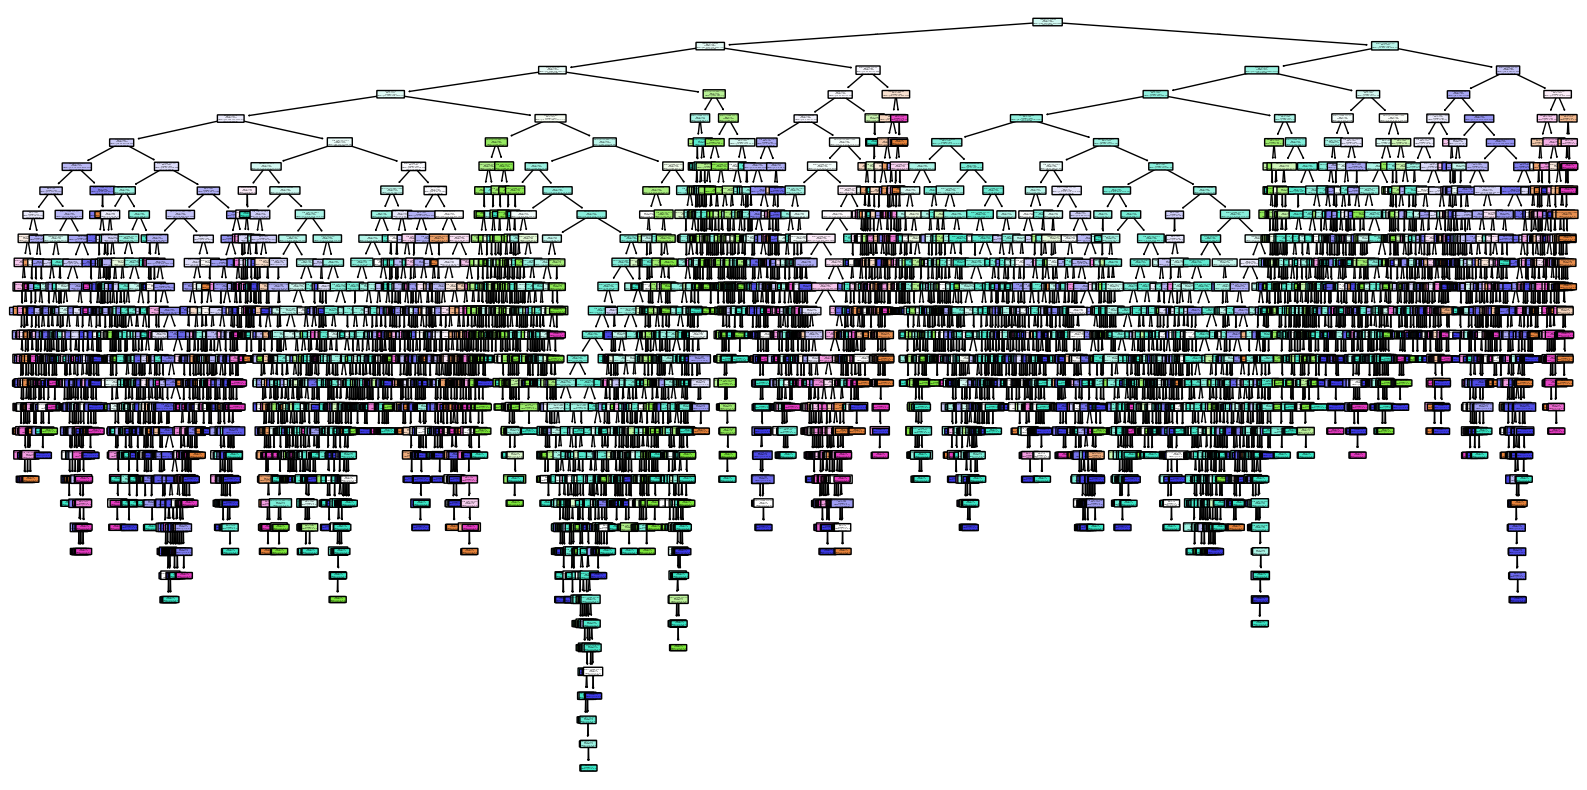

In [24]:
# Plot the tree
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
plot_tree(
    single_tree,
    feature_names=X.columns,
    class_names=y.unique(),  # Use your target class labels here
    filled=True,
    rounded=True
)
plt.show()

## RandomForest Classifier Hyperparameter Tuning

Parameters explanation : 

* n_estimators	More trees = better performance but slower computation.
* max_depth	Limits tree growth to prevent overfitting.
* min_samples_split	Controls how deep trees can grow; higher = less overfitting.
* min_samples_leaf	Prevents overfitting by requiring minimum samples in leaves.
* max_features	Reduces computation by limiting features at each split.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    scoring='accuracy',  # Adjust scoring metric as needed
    cv=3,  # 3-fold cross-validation
    verbose=2,
    n_jobs=-1  # Use all available cores
)

# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_rf_classifier = grid_search.best_estimator_

print("Best Parameters:", best_params)


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [16]:
# Predictions using the best model
y_pred_best = best_rf_classifier.predict(X_test)

# Classification report
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))


Accuracy: 0.7239372469635628
Classification Report:
               precision    recall  f1-score   support

        High       0.72      0.55      0.62       290
         Low       0.83      0.80      0.82       726
  Low_Medium       0.74      0.84      0.79      1540
      Medium       0.65      0.66      0.65       956
 Medium-High       0.65      0.45      0.53       440

    accuracy                           0.72      3952
   macro avg       0.72      0.66      0.68      3952
weighted avg       0.72      0.72      0.72      3952



##  SVM 

### Feature Scaling

In [9]:
# Standardize the features
from sklearn.discriminant_analysis import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Train an SVM Classifier

In [10]:
# Initialize the SVM classifier
from sklearn.svm import SVC


svm_classifier = SVC(kernel='rbf', random_state=42)

# Train the classifier
svm_classifier.fit(X_train_scaled, y_train)


SVC(random_state=42)

### Evaluate the Classifier

In [11]:
# Predict on test data
from sklearn.metrics import confusion_matrix


y_pred = svm_classifier.predict(X_test_scaled)

# Evaluate the classifier
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.43      0.52       290
         Low       0.79      0.68      0.73       726
  Low_Medium       0.66      0.84      0.74      1540
      Medium       0.53      0.58      0.56       956
 Medium-High       0.51      0.18      0.27       440

    accuracy                           0.64      3952
   macro avg       0.64      0.54      0.56      3952
weighted avg       0.64      0.64      0.63      3952

Confusion Matrix:
[[ 124    2   19   95   50]
 [   0  492  230    4    0]
 [   0  120 1290  130    0]
 [   8    6  357  559   26]
 [  51    1   50  259   79]]


##  SVM Hyperparameter Tuning

For Support Vector Machines (SVM), key hyperparameters include:

1. C: Regularization parameter.

* Controls the trade-off between a smooth decision boundary and correctly classifying training points.
* Smaller 𝐶: More regularization (allows misclassified points for better generalization).
* Larger 𝐶: Less regularization (fits the training data closely, risking overfitting).

2. Gamma (for rbf kernel):

* Defines the influence of a single data point.
* Small gamma: Models the relationships broadly.
* Large gamma: Captures fine details but may overfit.

3. Kernel: Type of decision boundary.

*  linear, rbf (Gaussian), poly, or sigmoid.

In [12]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Perform GridSearch
grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=2, cv=3)
grid.fit(X_train_scaled, y_train)

# Use the best model
best_svm = grid.best_estimator_

# Evaluate the best model
y_pred_best = best_svm.predict(X_test_scaled)
print("Best Model Classification Report:")
print(classification_report(y_test, y_pred_best))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  17.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  14.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  20.7s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  12.5s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  12.5s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  25.3s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  11.8s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  17.6s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=  19.4s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=  14.0s
[CV] END .....................C=0.1, gamma=0.001

In [13]:
# Retrieve the best hyperparameters
best_params = grid.best_params_
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
